# 04 - Geometry, Simulation Truth, And Lateral Distance

Three ideas here:

1. The GCD file tells us where DOMs are.
2. The simulation file can contain a true particle track.
3. We can calculate how far each pulsed DOM is from that track.


In [1]:
from pathlib import Path
from math import sin, cos

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from icecube import dataio, dataclasses

SIM_GCD = Path('/data/exp/IceCube/2020/filtered/level2/0101/Run00133575/Level2_IC86.2019_data_Run00133575_0101_78_503_GCD.i3.zst')
SIM_FILE = Path('/data/sim/IceCube/2020/filtered/level2/CORSIKA-in-ice/20904/0000000-0000999/Level2_IC86.2020_corsika.020904.000000.i3.zst')


## Read the geometry from the GCD file

The geometry (G) frame contains `I3Geometry`.

Inside it, `geometry.omgeo` maps each OMKey to a DOM position. For simplicity we keep standard in-ice DOMs and ignore IceTop.

Define a few helper functions:

In [2]:
def frame_stop(frame):  # <-- Naming convention mapping (for clarity)
    names = {'G': 'Geometry', 'C': 'Calibration', 'D': 'DetectorStatus', 'Q': 'DAQ', 'P': 'Physics', 'I': 'TrayInfo'}
    return names.get(str(frame.Stop), str(frame.Stop))


# I3Geometry key finder:
def read_geometry(gcd_path):
    gcd_file = dataio.I3File(str(gcd_path))  # read in the GCD file
    while gcd_file.more():                   # loop through all the frames
        frame = gcd_file.pop_frame()         # "pop" the next frame in sequence (starts with the first one).
        if frame_stop(frame) == 'Geometry' and 'I3Geometry' in frame:  # if this frame is the one we want (G-frame) and it has the I3Geometry key...
            geometry = frame['I3Geometry']   # ...then instantiate that key
            gcd_file.close()
            return geometry                  # and return it :)
    gcd_file.close()
    raise RuntimeError('No I3Geometry found in the GCD file.')


# Check if the DOM we're looking at is in fact an in-ice DOM:
def is_inice_dom(omkey):
    return 1 <= omkey.string <= 86 and 1 <= omkey.om <= 60  # <-- 86 strings comprising IceCube. 60 DOMs per string.


# Collect the x,y,z position of a given DOM (a given omkey), for which we also must provide the I3Geometry key (or "geometry"):
def dom_position_xyz(geometry, omkey):
    position = geometry.omgeo[omkey].position
    return np.array([position.x, position.y, position.z], dtype=float)

geometry = read_geometry(SIM_GCD)
inice_positions = {omkey: dom_position_xyz(geometry, omkey) for omkey in geometry.omgeo.keys() if is_inice_dom(omkey)}
print('Number of in-ice DOM positions loaded:', len(inice_positions))

# A few examples of what we just collected in the 'inice_positions' dictionary:
dom_ids = list(inice_positions.keys())
dom_pos = list(inice_positions.values())
for i in range(10):
    print(dom_ids[i], '     is located at     ', dom_pos[i])

Number of in-ice DOM positions loaded: 5160
OMKey(1,1,0)      is located at      [-256.14 -521.08  496.03]
OMKey(1,2,0)      is located at      [-256.14 -521.08  479.01]
OMKey(1,3,0)      is located at      [-256.14 -521.08  461.99]
OMKey(1,4,0)      is located at      [-256.14 -521.08  444.97]
OMKey(1,5,0)      is located at      [-256.14 -521.08  427.95]
OMKey(1,6,0)      is located at      [-256.14 -521.08  410.93]
OMKey(1,7,0)      is located at      [-256.14 -521.08  393.91]
OMKey(1,8,0)      is located at      [-256.14 -521.08  376.88]
OMKey(1,9,0)      is located at      [-256.14 -521.08  359.86]
OMKey(1,10,0)      is located at      [-256.14 -521.08  342.84]


## Plot the detector from above

These are the x-y positions of in-ice DOMs (or rather the strings from a bird's eye view).

Notice that this wasn't a pre-loaded map. We found it directly from the OMKey and geometry key.


Text(0.5, 1.0, 'InIce DOM positions, viewed from above')

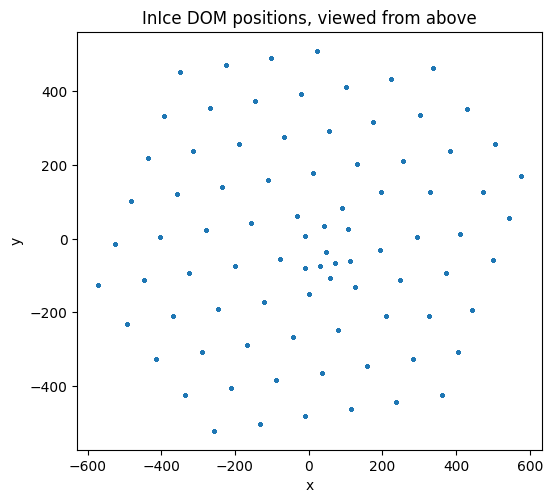

In [3]:
geometry_rows = []
for omkey, position in inice_positions.items():
    geometry_rows.append({'string': omkey.string, 'om': omkey.om, 'x': position[0], 'y': position[1], 'z': position[2]})

geometry_table = pd.DataFrame(geometry_rows)
ax = geometry_table.plot.scatter(x='x', y='y', s=4, alpha=0.4, figsize=(6, 6))
ax.set_aspect('equal')
ax.set_title('InIce DOM positions, viewed from above')


## Pulse and truth helpers

The next functions
1. find a pulse map,
2. find a truth-track-like particle, and
3. calculate distance from a point to a line.

For distance: subtract the track point from the DOM point, cross with the unit direction vector, and take the length. Same as in the Moon Shadow scripts just now with .i3-pulled information.


In [4]:
def find_pulse_key(frame):  # Finds a key with the pulses.
    for key in ['SplitInIcePulses', 'SplitInIceDSTPulses', 'SRTInIcePulses', 'InIcePulses', 'OfflinePulses']:
        if key in frame:
            return key
    return None


def pulsed_omkeys(frame):
    pulse_key = find_pulse_key(frame)  # With the pulse key...
    if pulse_key is None:
        return pulse_key, []
    pulse_map = dataclasses.I3RecoPulseSeriesMap.from_frame(frame, pulse_key)  # ...find the omkeys and corresponding pulses in the event.
    return pulse_key, [omkey for omkey, pulses in pulse_map if len(pulses) > 0 and is_inice_dom(omkey)]


def looks_like_particle(obj):  # Makes sure that the key we're looking at is a reconstructed 'PrimaryParticle' with direction/position info
    return hasattr(obj, 'pos') and hasattr(obj, 'dir')


def find_truth_particle(frame):
    preferred_keys = ['MCPrimary', 'MostEnergeticMuon', 'MostEnergeticInIceMuon', 'MCMuon', 'PolyplopiaPrimary']
    for key in preferred_keys:
        if key in frame and looks_like_particle(frame[key]):
            return key, frame[key]  # Returns the reconstructed 'PrimaryParticle' key we found and the contained values.

    # Fall back to any particle-like key with a useful name.
    for key in frame.keys():
        lower = key.lower()
        if any(word in lower for word in ['mc', 'truth', 'primary', 'muon']):
            try:
                if looks_like_particle(frame[key]):
                    return key, frame[key]
            except Exception:
                pass
    return None, None


def particle_position(particle):  # Finds the "position" of the particle (no idea what the definition is -- doesn't really matter).
    return np.array([particle.pos.x, particle.pos.y, particle.pos.z], dtype=float)


def particle_direction_unit_vector(particle):
    zenith = particle.dir.zenith
    azimuth = particle.dir.azimuth
    direction = np.array([sin(zenith) * cos(azimuth), sin(zenith) * sin(azimuth), cos(zenith)], dtype=float)
    return direction / np.linalg.norm(direction)


def distance_from_dom_to_track(dom_xyz, particle):
    track_point = particle_position(particle)
    # print(track_point)
    track_direction = particle_direction_unit_vector(particle)
    return np.linalg.norm(np.cross(dom_xyz - track_point, track_direction))


## Build the lateral-distance table

Now loop through simulation P-frames.

For each event, find pulsed DOMs and a truth track. If both exist, calculate one distance *per pulsed DOM.*


In [5]:
MAX_PHYSICS_FRAMES = 500
MIN_HIT_DOMS = 1

rows = []
physics_seen = 0
events_with_pulses = 0
events_with_truth = 0
first_pulse_key = None
first_truth_key = None
interesting_keys = []

i3_file = dataio.I3File(str(SIM_FILE))
while i3_file.more() and physics_seen < MAX_PHYSICS_FRAMES:
    frame = i3_file.pop_frame()
    if frame_stop(frame) != 'Physics':
        continue

    physics_seen += 1
    if not interesting_keys:
        interesting_keys = [key for key in frame.keys() if any(word in key.lower() for word in ['pulse', 'mc', 'muon', 'primary', 'truth'])]

    pulse_key, omkeys = pulsed_omkeys(frame)
    if pulse_key is not None:
        first_pulse_key = first_pulse_key or pulse_key
    if len(omkeys) < MIN_HIT_DOMS:
        continue
    events_with_pulses += 1

    truth_key, truth_particle = find_truth_particle(frame)
    if truth_particle is None:
        continue
    events_with_truth += 1
    first_truth_key = first_truth_key or truth_key

    event_id = frame['I3EventHeader'].event_id if 'I3EventHeader' in frame else None
    for omkey in omkeys:
        distance_m = distance_from_dom_to_track(inice_positions[omkey], truth_particle)
        rows.append({'event_id': event_id, 'string': omkey.string, 'om': omkey.om, 'truth_key': truth_key, 'distance_m': distance_m, 'event_hit_doms': len(omkeys)})

i3_file.close()
distance_table = pd.DataFrame(rows, columns=['event_id', 'string', 'om', 'truth_key', 'distance_m', 'event_hit_doms'])

print('Physics frames inspected:', physics_seen)
print('Events with enough pulsed DOMs:', events_with_pulses)
print('Events with a truth particle:', events_with_truth)
print('First pulse key found:', first_pulse_key)
print('First truth key found:', first_truth_key)
print('Interesting keys from first Physics frame:', interesting_keys[:30])
distance_table.head(15)


Physics frames inspected: 500
Events with enough pulsed DOMs: 500
Events with a truth particle: 500
First pulse key found: InIcePulses
First truth key found: PolyplopiaPrimary
Interesting keys from first Physics frame: ['BackgroundMMCTrackList', 'OfflineIceTopSLCVEMPulses', 'OfflineIceTopHLCTankPulses', 'IceTopPulses', 'MMCTrackList', 'IceTopDSTPulses', 'TankPulseMergerExcludedTanks', 'BackgroundI3MCTree_preMuonProp', 'PolyplopiaPrimary', 'OfflineIceTopHLCVEMPulses', 'BackgroundI3MCTreePEcounts', 'InIceDSTPulses', 'BackgroundI3MCTree', 'InIcePulses', 'UncleanedInIcePulsesTimeRange', 'I3MCPulseSeriesMapPrimaryIDMap', 'I3MCTree_preMuonProp', 'I3MCTreePEcounts', 'I3MCPulseSeriesMap', 'I3MCPulseSeriesMapParticleIDMap']


,event_id,string,om,truth_key,distance_m,event_hit_doms
0,1,2,9,PolyplopiaPrimary,72.370379,37
1,1,2,13,PolyplopiaPrimary,56.355535,37
2,1,2,22,PolyplopiaPrimary,42.354352,37
3,1,3,22,PolyplopiaPrimary,93.316124,37
4,1,3,51,PolyplopiaPrimary,223.516595,37
5,1,5,12,PolyplopiaPrimary,317.800578,37
6,1,5,35,PolyplopiaPrimary,374.944950,37
7,1,8,19,PolyplopiaPrimary,135.388539,37
8,1,8,40,PolyplopiaPrimary,55.448357,37
9,1,8,42,PolyplopiaPrimary,53.869733,37


## Plot the distances

If the table is empty, do not panic. That usually means the chosen file does not have the truth key we expected, or the pulse key list needs to be adjusted. The previous cell prints clues.


Each histogram entry is one pulsed DOM, not one event.


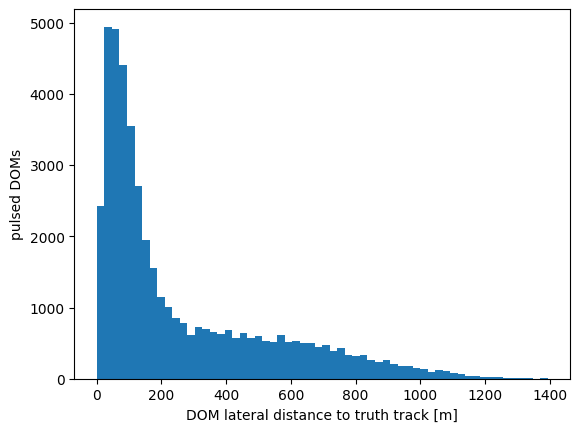

In [6]:
if distance_table.empty:
    print('No lateral-distance rows were built. Look at the diagnostic output above.')
else:
    distance_table['distance_m'].plot.hist(bins=60)
    plt.xlabel('DOM lateral distance to truth track [m]')
    plt.ylabel('pulsed DOMs')
    print('Each histogram entry is one pulsed DOM, not one event.')


## Practice

1. Print `distance_table.groupby('event_id')['distance_m'].median()` to get one value per event. Make a histogram of these as well.
2. Try changing the preferred truth keys in `find_truth_particle`.
3. Instead of a histogram, generate a scatterplot pulse charge over lateral distance for single events.

What we eventually want to do is something like step 3, but grab a single statistical value from it, then compare that value for showers from proton vs. iron (light vs. heavy) cosmic rays.
- The cosmic ray type or "primary particle" will be stored in the truth key of the simulation (PolyplopiaPrimary for this dataset).
- Use dataio-shovel to see again the contents of PolyplopiaPrimary. (See the bottom of notebook _01).
- You can see what "Type" string corresponds to a 'p' or 'He' or 'O' or 'N' or 'Fe' particle by printing out that string for a bunch of frames (or only printing whenever a unique string emerges in the loop).
- With that information you can sort particles by their Type.
    - This will eventually need to be done on billions of events. For that we need a more compact way to store the selected data. This is what .hdf5 files are for (see notebook _05).
